# Week 1 – Data Cleaning with Python, pandas & NumPy

This notebook demonstrates the core concepts:
- Loading and inspecting CSV data
- Understanding DataFrames
- Finding and handling missing values
- Removing duplicates
- Basic cleaning steps
- Simple NumPy operations
- Visualizing the data with Matplotlib

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 2. Load Dataset

We load the laptop dataset using `pd.read_csv()`. This creates a pandas **DataFrame** – a table of rows and columns similar to a spreadsheet.

In [4]:
df = pd.read_csv("data/laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## 3. Understand the Dataset

These methods help us quickly see the structure and content of the data.

In [5]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape (rows, columns): (1303, 12)

Column names:
['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [7]:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


In [8]:
print("Data types:")
print(df.dtypes)

Data types:
Unnamed: 0          float64
Company              object
TypeName             object
Inches               object
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object


## 4. Data Quality Analysis

Before cleaning we check for common problems: missing values, duplicate rows, and the number of unique values in each column.

In [9]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

Total missing values: 360


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 29


In [11]:
print("Unique values per column:")
print(df.nunique())

Unique values per column:
Unnamed: 0          1273
Company               19
TypeName               6
Inches                25
ScreenResolution      40
Cpu                  118
Ram                   10
Memory                40
Gpu                  110
OpSys                  9
Weight               189
Price                777
dtype: int64


In [12]:
# Quick look at the distribution of the Price column (the only fully numeric column)
print("Price statistics:")
print(df["Price"].describe())

Price statistics:
count      1273.000000
mean      59955.814073
std       37332.251005
min        9270.720000
25%       31914.720000
50%       52161.120000
75%       79333.387200
max      324954.720000
Name: Price, dtype: float64


## 5. Data Cleaning

We apply the same steps used by the CLI tool.

In [13]:
# Keep a copy of the original for the before/after comparison later
original_df = df.copy()
original_shape = original_df.shape
original_missing = original_df.isnull().sum().sum()
original_duplicates = original_df.duplicated().sum()

print("Original shape:", original_shape)
print("Original missing:", original_missing)
print("Original duplicates:", original_duplicates)

Original shape: (1303, 12)
Original missing: 360
Original duplicates: 29


### 5.1 Clean column names
Remove any accidental leading or trailing spaces from column names.

In [14]:
df.columns = df.columns.str.strip()
print("Column names after cleaning:", df.columns.tolist())

Column names after cleaning: ['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']


### 5.2 Remove completely empty rows and columns
`dropna(how='all')` drops a row only if every value in that row is missing.

In [15]:
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")
print("Shape after removing empty rows/columns:", df.shape)

Shape after removing empty rows/columns: (1273, 12)


### 5.3 Strip whitespace from text columns
Object columns often contain extra spaces that can cause problems later.

In [16]:
for col in df.select_dtypes(exclude=[np.number]).columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)
print("Text columns cleaned.")


Text columns cleaned.


### 5.4 Remove duplicate rows
`drop_duplicates()` keeps the first occurrence of each unique row and removes the rest.

In [17]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1273, 12)


### 5.5 Impute missing values
- **Numeric columns** → fill with the **median** (middle value). Median is robust to extreme values.
- **Categorical / text columns** → fill with the **mode** (most frequent value).

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

missing_before = df.isnull().sum().sum()

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])

missing_after = df.isnull().sum().sum()
print(f"\nMissing values before imputation: {missing_before}")
print(f"Missing values after imputation:  {missing_after}")
print(f"Values filled: {missing_before - missing_after}")

Numeric columns: ['Unnamed: 0', 'Price']
Categorical columns: ['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']

Missing values before imputation: 0
Missing values after imputation:  0
Values filled: 0


## 6. NumPy Practice

NumPy works with arrays and is useful for quick numeric calculations.

In [19]:
# Create a NumPy array from the Price column
prices = df["Price"].to_numpy()
print("Array shape:", prices.shape)
print("First 5 prices:", prices[:5])

Array shape: (1273,)
First 5 prices: [ 71378.6832  47895.5232  30636.     135195.336   96095.808 ]


In [20]:
print("Mean price:", np.mean(prices))
print("Median price:", np.median(prices))
print("Min price:", np.min(prices))
print("Max price:", np.max(prices))

Mean price: 59955.81407321288
Median price: 52161.12
Min price: 9270.72
Max price: 324954.72


In [21]:
# Simple arithmetic – scale all prices by 0.01 (e.g. convert units)
scaled = prices * 0.01
print("Scaled first 5:", scaled[:5])

Scaled first 5: [ 713.786832  478.955232  306.36     1351.95336   960.95808 ]


## 7. Visualizations

A few charts that help us understand the cleaned laptop data.

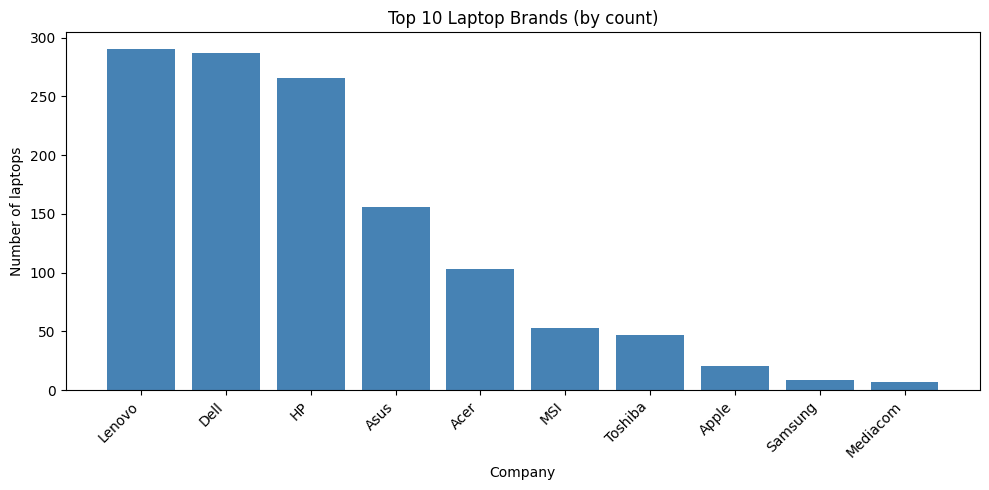

This bar chart shows which brands appear most often in the dataset.


In [22]:
# Chart 1: Number of laptops by Company
company_counts = df["Company"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(company_counts.index, company_counts.values, color="steelblue")
plt.title("Top 10 Laptop Brands (by count)")
plt.xlabel("Company")
plt.ylabel("Number of laptops")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("This bar chart shows which brands appear most often in the dataset.")

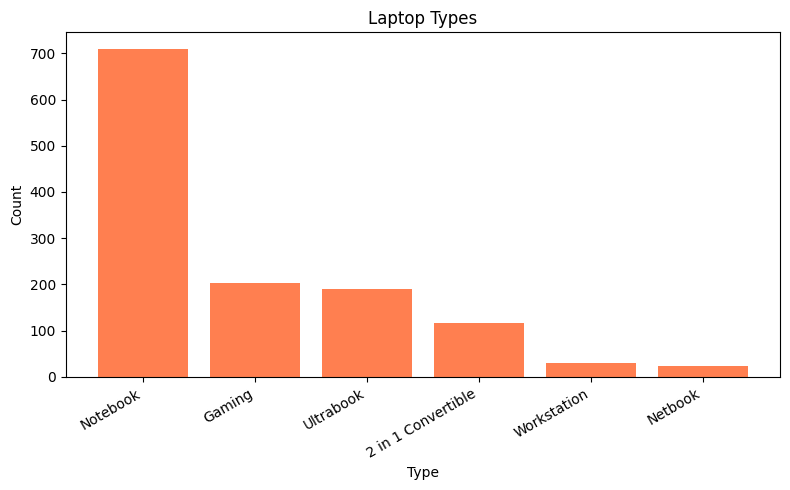

Notebook is the most common type, followed by Gaming and Ultrabook.


In [23]:
# Chart 2: Distribution of laptop types
type_counts = df["TypeName"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values, color="coral")
plt.title("Laptop Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Notebook is the most common type, followed by Gaming and Ultrabook.")

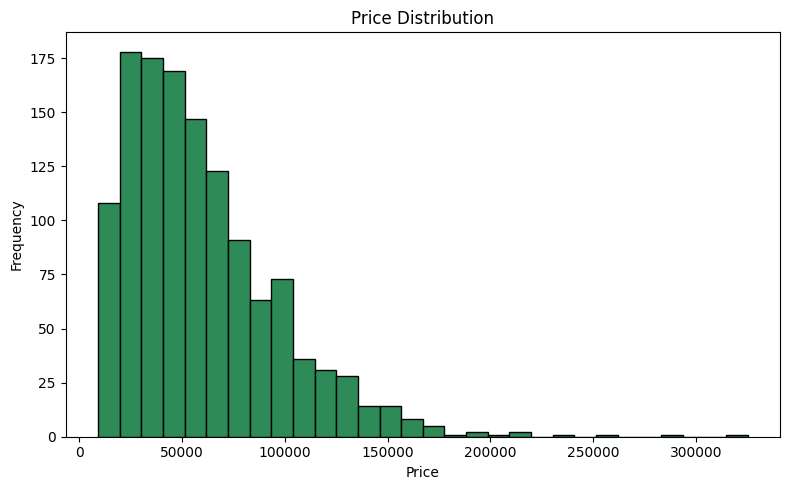

Most laptops are priced in the lower-to-middle range; a few expensive models create a long right tail.


In [24]:
# Chart 3: Price distribution (histogram)
plt.figure(figsize=(8, 5))
plt.hist(df["Price"], bins=30, color="seagreen", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Most laptops are priced in the lower-to-middle range; a few expensive models create a long right tail.")

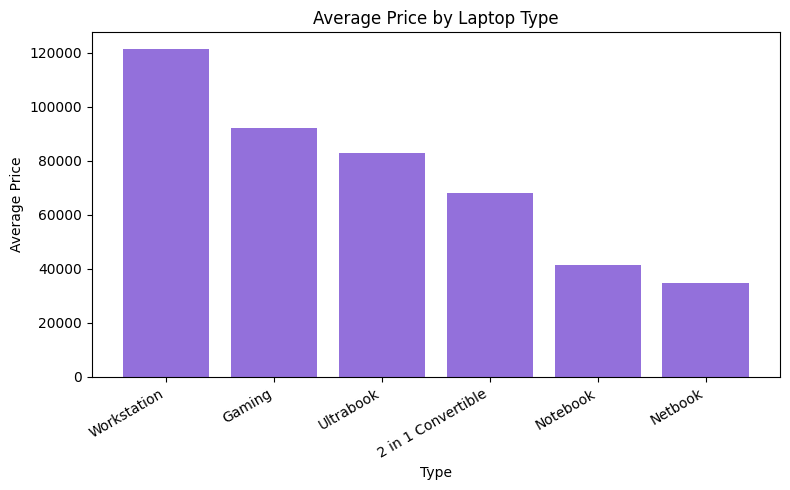

Workstations and Gaming laptops tend to have higher average prices than Notebooks.


In [25]:
# Chart 4: Average price by TypeName
avg_price = df.groupby("TypeName")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(avg_price.index, avg_price.values, color="mediumpurple")
plt.title("Average Price by Laptop Type")
plt.xlabel("Type")
plt.ylabel("Average Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Workstations and Gaming laptops tend to have higher average prices than Notebooks.")

## 8. Before vs After

In [26]:
print("=== Before vs After Cleaning ===")
print(f"Original shape:          {original_shape}")
print(f"Cleaned shape:           {df.shape}")
print(f"Original missing values: {original_missing}")
print(f"Cleaned missing values:  {df.isnull().sum().sum()}")
print(f"Original duplicate rows: {original_duplicates}")
print(f"Cleaned duplicate rows:  {df.duplicated().sum()}")

=== Before vs After Cleaning ===
Original shape:          (1303, 12)
Cleaned shape:           (1273, 12)
Original missing values: 360
Cleaned missing values:  0
Original duplicate rows: 29
Cleaned duplicate rows:  0


## 9. Export Cleaned Dataset

In [27]:
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned dataset saved as cleaned_data.csv")

Cleaned dataset saved as cleaned_data.csv
